In [34]:
import sys
import os
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter as Counter
from random import randint

In [35]:
env = gym.make("Taxi-v3", render_mode = 'ansi')
env.reset()
env.render()
n_states = env.observation_space.n 
n_actions = env.action_space.n 
print("n_states=%i, n_actions=%i" % (n_states, n_actions))

n_states=500, n_actions=6


In [36]:
def initialize_policy(n_states, n_actions):
    return np.full((n_states, n_actions), 1 / n_actions)

policy = initialize_policy(n_states, n_actions)

assert type(policy) in (np.ndarray, np.matrix)
assert np.allclose(policy, 1 / n_actions)
assert np.allclose(np.sum(policy, axis=1), 1)

In [37]:
def generate_session(env, policy, t_max=10**4):
    states, actions = [], []
    total_reward = 0.0

    s = env.reset()[0]
    for t in range(t_max):
        a = np.random.choice(len(policy[s]), p=policy[s])
        new_s, r, terminated, truncated, info = env.step(a)
        done = (terminated or truncated)
        states.append(s)
        actions.append(a)
        total_reward += r
        s = new_s
        if(done):
            break
    return states, actions, total_reward

s, a, r = generate_session(env, policy)

assert type(s) == type(a) == list
assert len(s) == len(a)
assert type(r) in [float, np.float64]

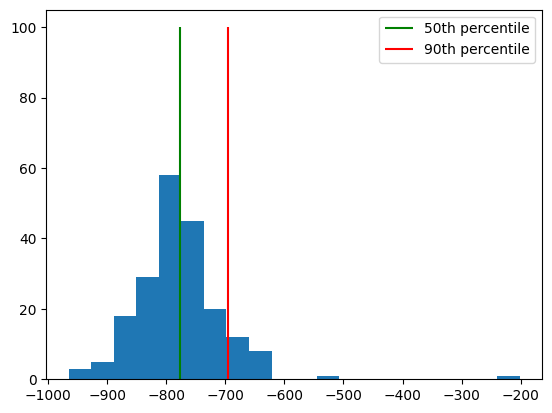

In [38]:
sample_rewards = [generate_session(env, policy, t_max=1000)[-1] for _ in range(200)]

plt.hist(sample_rewards, bins=20)
plt.vlines([np.percentile(sample_rewards, 50)], [0], [100], label='50th percentile', color='green')
plt.vlines([np.percentile(sample_rewards, 90)], [0], [100], label='90th percentile', color='red')
plt.legend()
plt.show()

In [39]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile):
    
    reward_threshold = np.percentile(rewards_batch, percentile)
    indices = np.where(rewards_batch >= reward_threshold)
    elite_states = []
    elite_actions = []
    for i in indices[0]:
        elite_states.extend(states_batch[i])
        elite_actions.extend(actions_batch[i])

    return elite_states, elite_actions


states_batch = [ 
    [1, 2, 3],
    [4, 2, 0, 2],
    [3, 1],
]
actions_batch = [ 
    [0, 2, 4], 
    [3, 2, 0, 1], 
    [3, 3], ] 
rewards_batch = [ 3,  4, 5, ]

test_result_0 = select_elites(states_batch, actions_batch, rewards_batch, percentile=0)
test_result_30 = select_elites(states_batch, actions_batch, rewards_batch, percentile=30)
test_result_90 = select_elites(states_batch, actions_batch, rewards_batch, percentile=90)
test_result_100 = select_elites(states_batch, actions_batch, rewards_batch, percentile=100)


assert np.all(test_result_0[0] == [1, 2, 3, 4, 2, 0, 2, 3, 1]) \
    and np.all(test_result_0[1] == [0, 2, 4, 3, 2, 0, 1, 3, 3])

assert np.all(test_result_30[0] == [4, 2, 0, 2, 3, 1]) \
    and np.all(test_result_30[1] == [3, 2, 0, 1, 3, 3])

assert np.all(test_result_90[0] == [3, 1]) \
    and np.all(test_result_90[1] == [3, 3])

assert np.all(test_result_100[0] == [3, 1]) \
    and np.all(test_result_100[1] == [3, 3])

In [40]:
def get_new_policy(elite_states, elite_actions):
    new_policy = np.full((n_states, n_actions), 1 / n_actions)
    actions_entries_count = len(elite_actions)
    if(actions_entries_count == 0):
        return new_policy
    counter = Counter(elite_actions)
    temp_array = np.zeros(n_actions)
    for key in counter.keys():
        temp_array[key] = counter[key] / actions_entries_count
    for s in set(elite_states):
        new_policy[s] = temp_array

    return new_policy

elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile=30)
policy = get_new_policy(elite_states, elite_actions)


mean reward = -776.296, threshold=-776.000


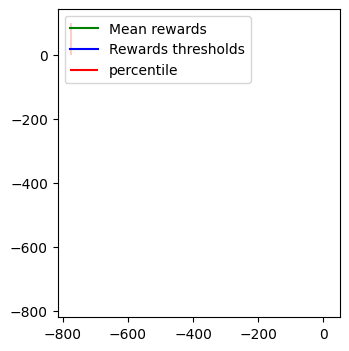

mean reward = -757.676, threshold=-767.000


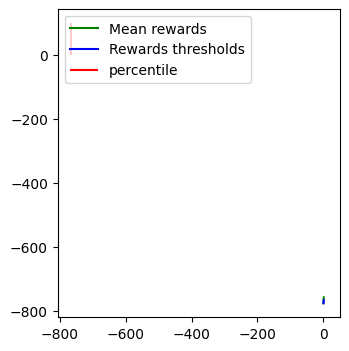

mean reward = -733.228, threshold=-749.000


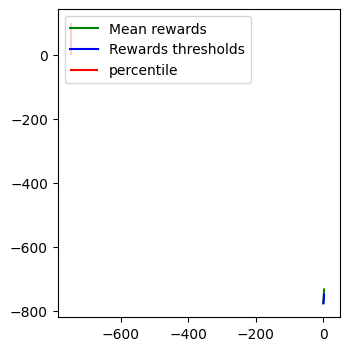

mean reward = -720.572, threshold=-731.000


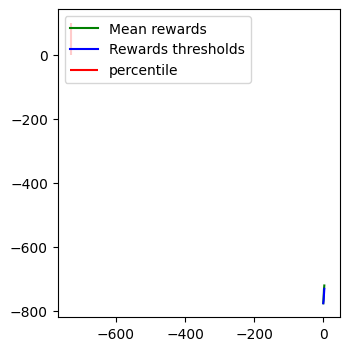

mean reward = -696.976, threshold=-695.000


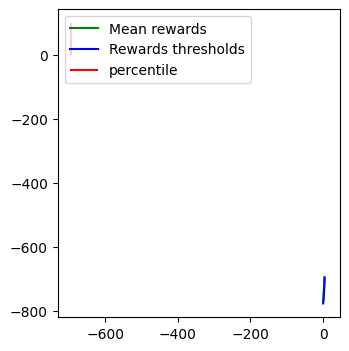

mean reward = -670.656, threshold=-686.000


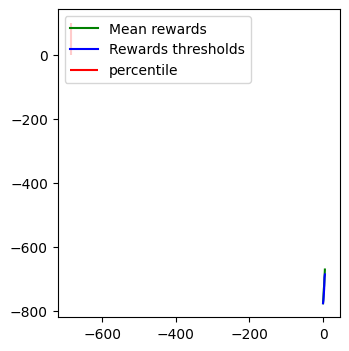

mean reward = -654.832, threshold=-668.000


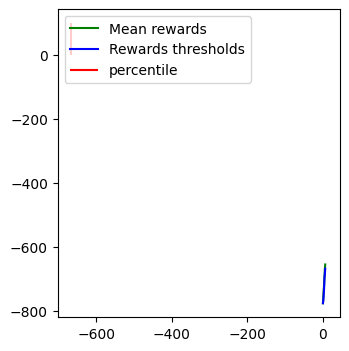

mean reward = -648.692, threshold=-650.000


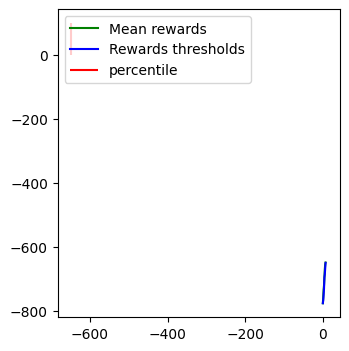

mean reward = -617.216, threshold=-627.500


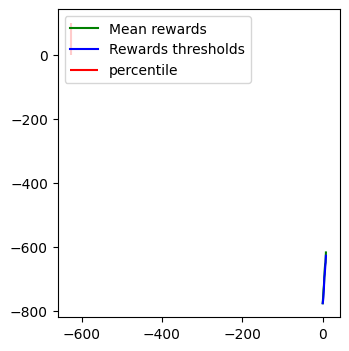

mean reward = -604.692, threshold=-614.000


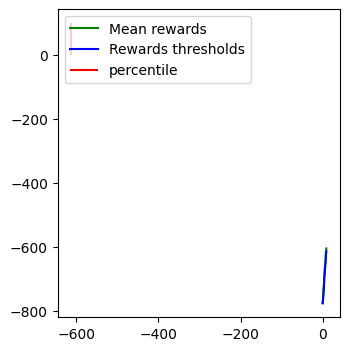

mean reward = -578.184, threshold=-587.000


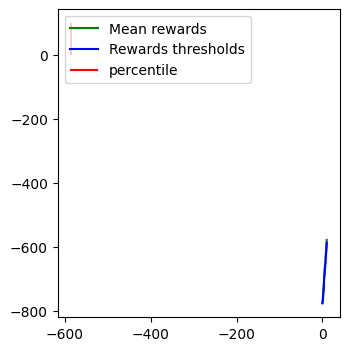

mean reward = -569.808, threshold=-569.000


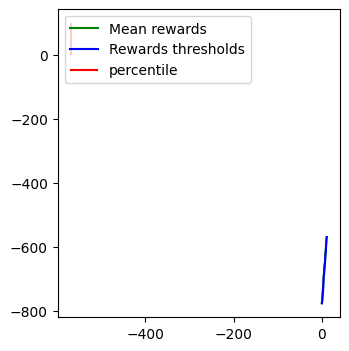

mean reward = -553.728, threshold=-560.000


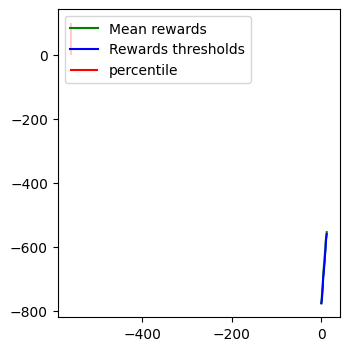

mean reward = -533.968, threshold=-533.000


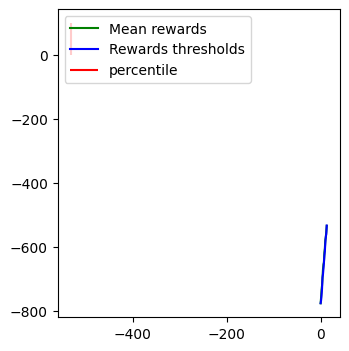

mean reward = -517.776, threshold=-524.000


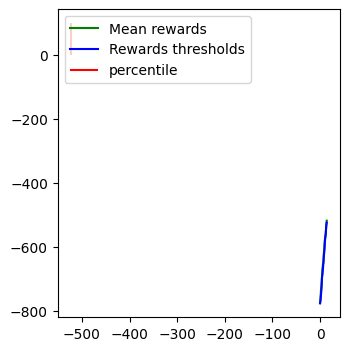

mean reward = -502.540, threshold=-515.000


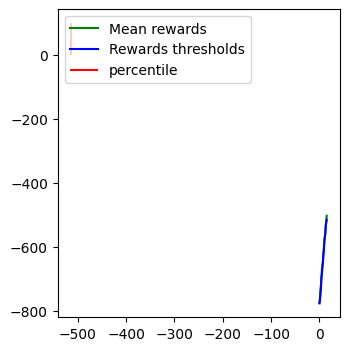

mean reward = -493.592, threshold=-497.000


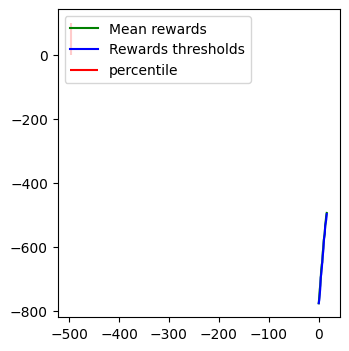

mean reward = -477.792, threshold=-479.000


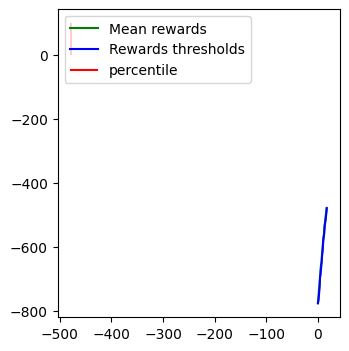

mean reward = -462.224, threshold=-470.000


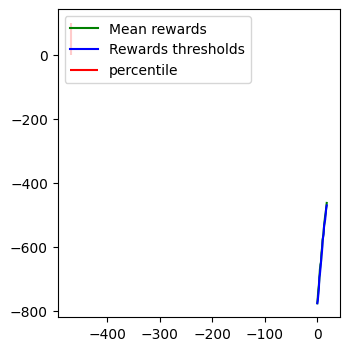

mean reward = -447.852, threshold=-452.000


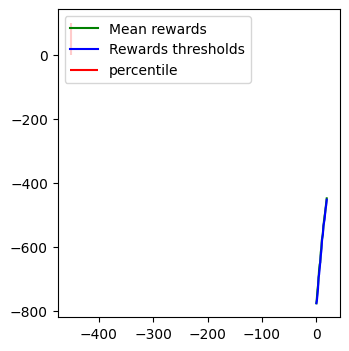

mean reward = -428.828, threshold=-434.000


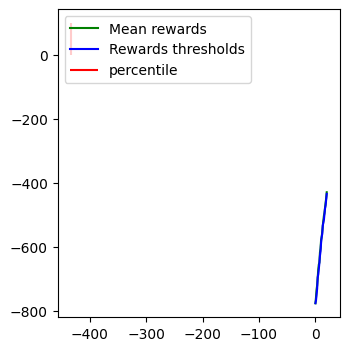

mean reward = -415.024, threshold=-416.000


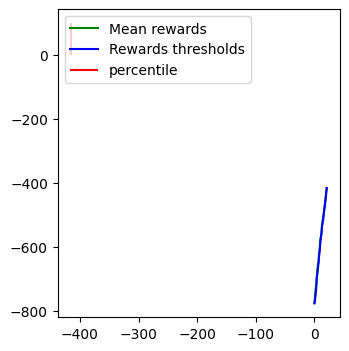

mean reward = -404.504, threshold=-407.000


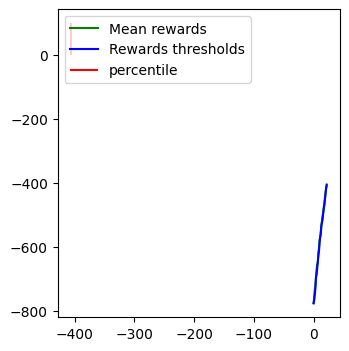

mean reward = -390.048, threshold=-389.000


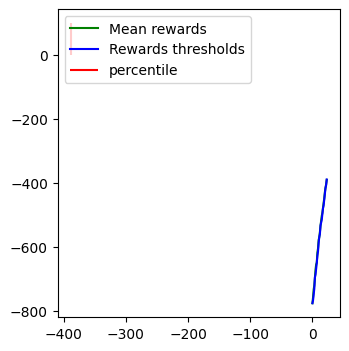

mean reward = -382.504, threshold=-380.000


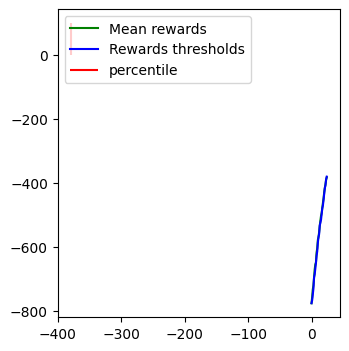

mean reward = -369.528, threshold=-371.000


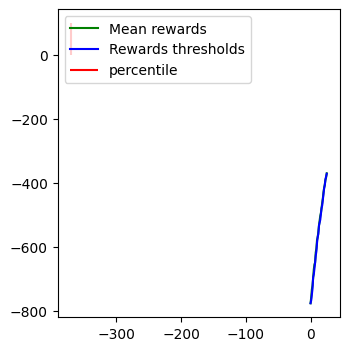

mean reward = -360.576, threshold=-362.000


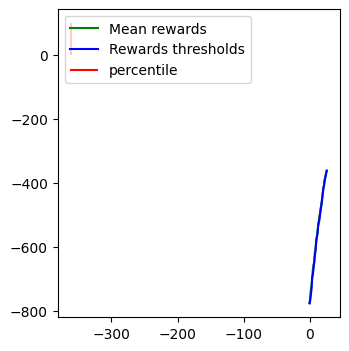

mean reward = -346.588, threshold=-344.000


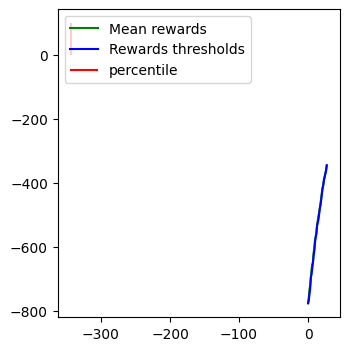

mean reward = -333.740, threshold=-335.000


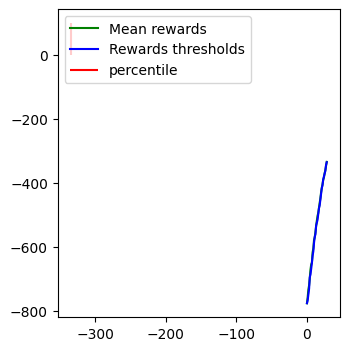

mean reward = -321.616, threshold=-326.000


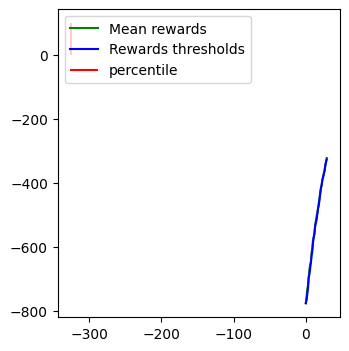

mean reward = -312.128, threshold=-308.000


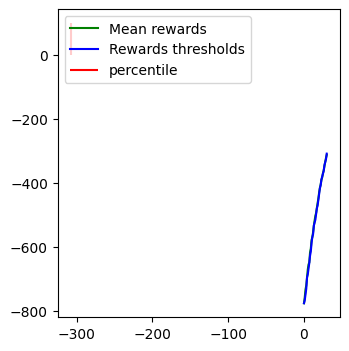

mean reward = -300.076, threshold=-299.000


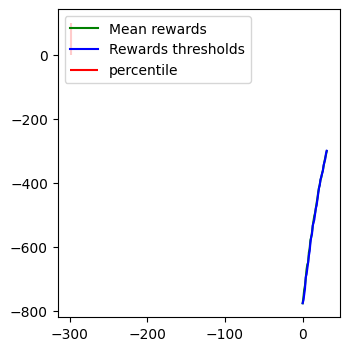

mean reward = -290.212, threshold=-290.000


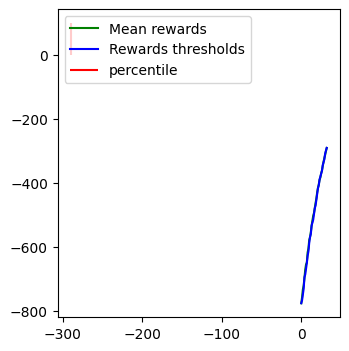

mean reward = -276.420, threshold=-281.000


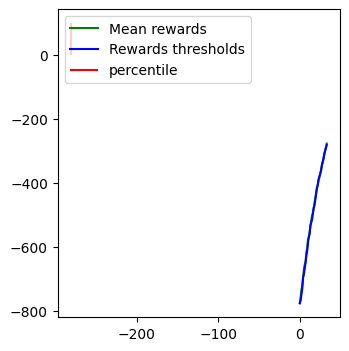

mean reward = -269.592, threshold=-272.000


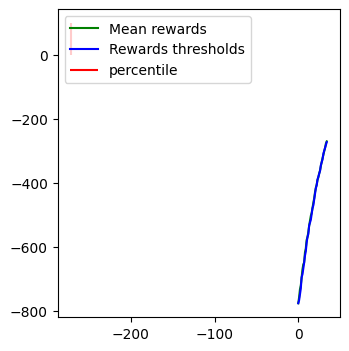

mean reward = -265.012, threshold=-263.000


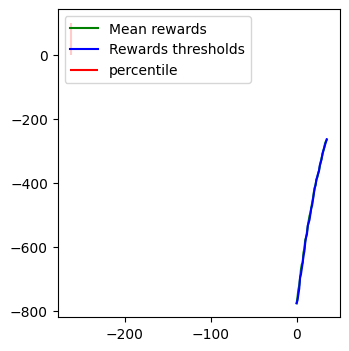

mean reward = -259.132, threshold=-254.000


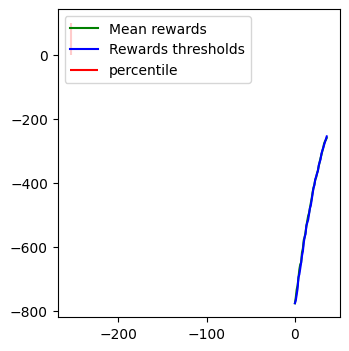

mean reward = -252.580, threshold=-245.000


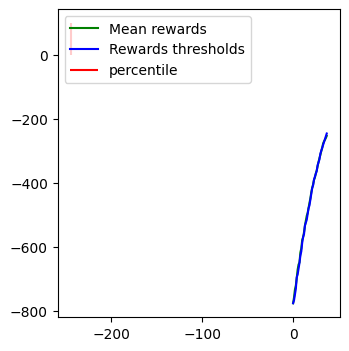

mean reward = -244.828, threshold=-245.000


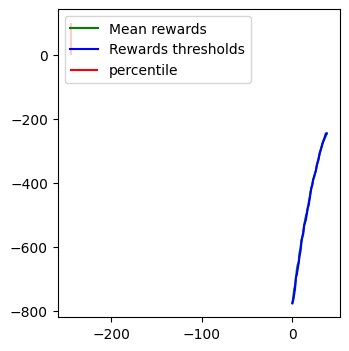

mean reward = -238.204, threshold=-236.000


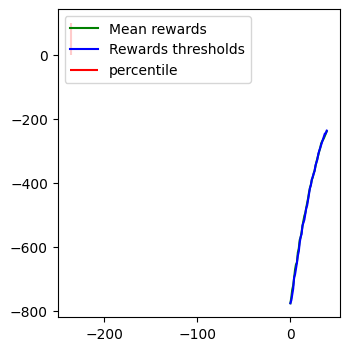

mean reward = -236.972, threshold=-236.000


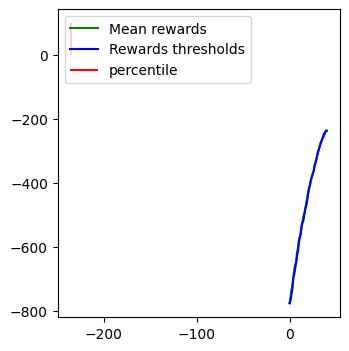

mean reward = -237.000, threshold=-227.000


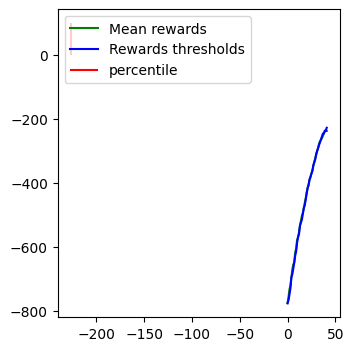

mean reward = -228.280, threshold=-227.000


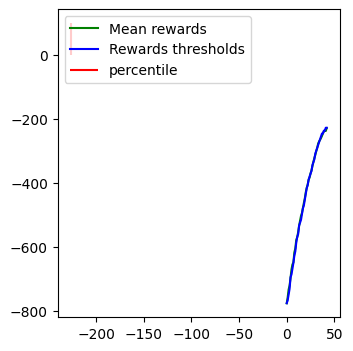

mean reward = -222.752, threshold=-218.000


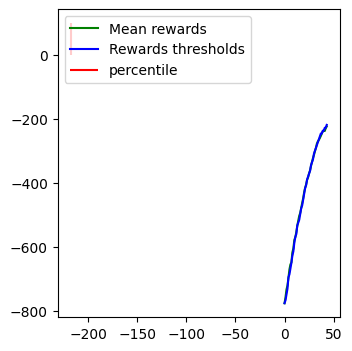

mean reward = -220.412, threshold=-209.000


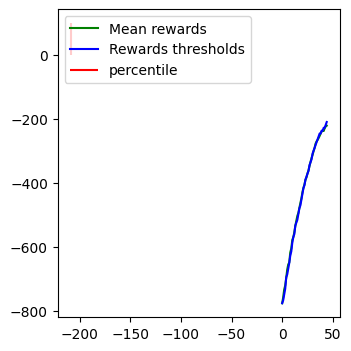

mean reward = -211.916, threshold=-209.000


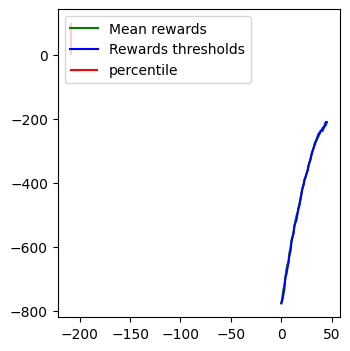

mean reward = -210.152, threshold=-209.000


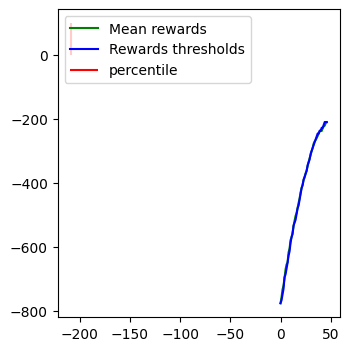

mean reward = -206.336, threshold=-200.000


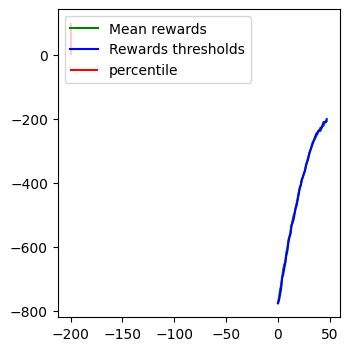

mean reward = -203.996, threshold=-200.000


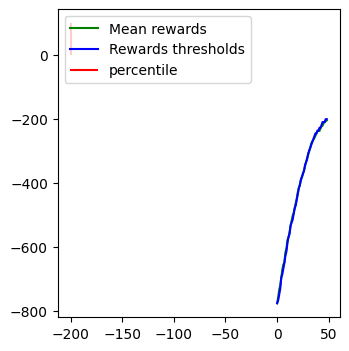

mean reward = -202.736, threshold=-200.000


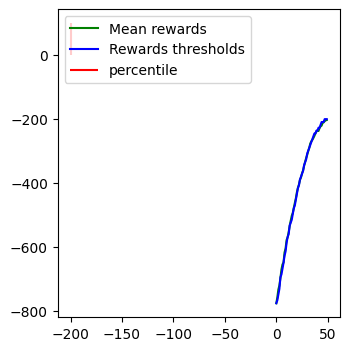

mean reward = -200.432, threshold=-200.000


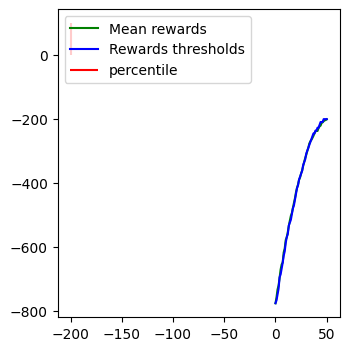

mean reward = -200.180, threshold=-200.000


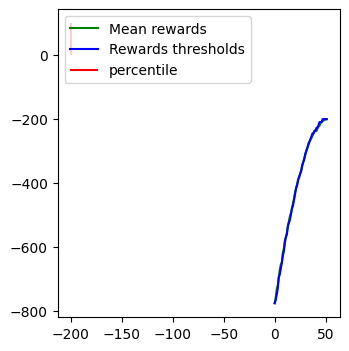

mean reward = -200.144, threshold=-200.000


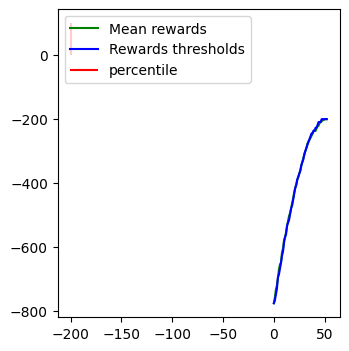

mean reward = -200.036, threshold=-200.000


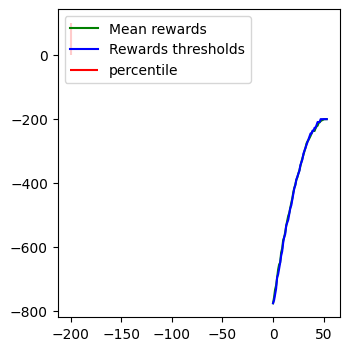

mean reward = -200.108, threshold=-200.000


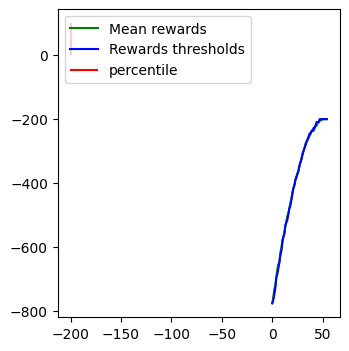

mean reward = -200.036, threshold=-200.000


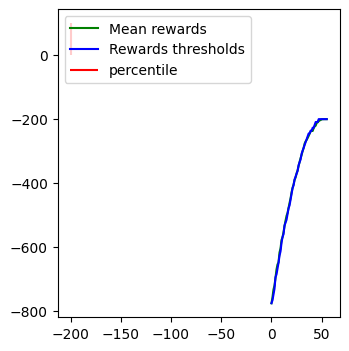

mean reward = -200.072, threshold=-200.000


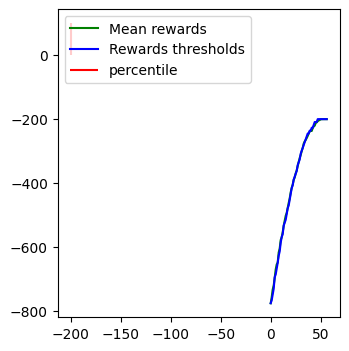

mean reward = -200.000, threshold=-200.000


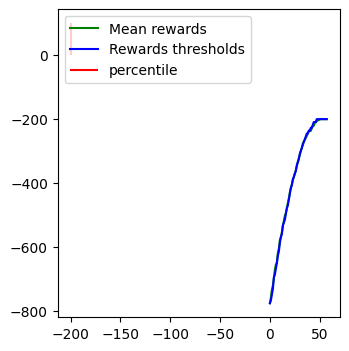

mean reward = -200.000, threshold=-200.000


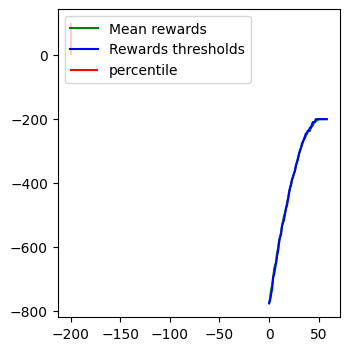

mean reward = -200.000, threshold=-200.000


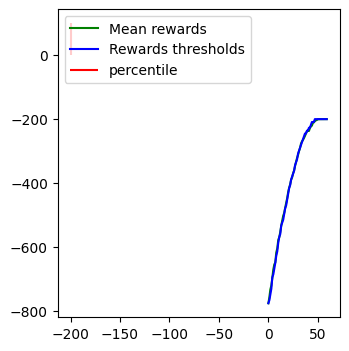

mean reward = -200.000, threshold=-200.000


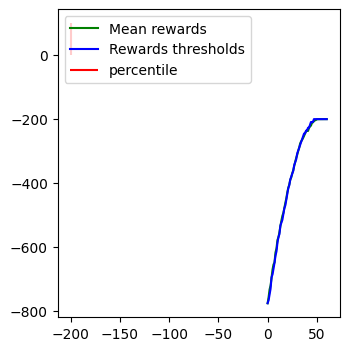

mean reward = -200.000, threshold=-200.000


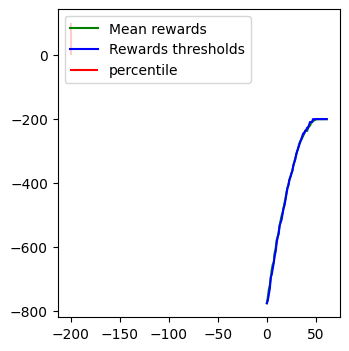

mean reward = -200.000, threshold=-200.000


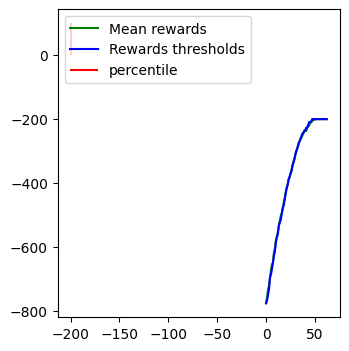

mean reward = -200.000, threshold=-200.000


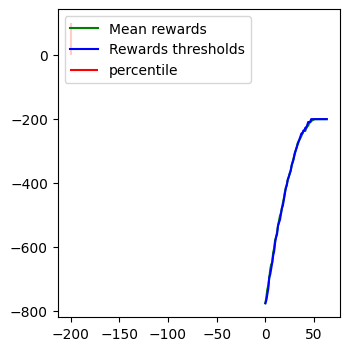

mean reward = -200.000, threshold=-200.000


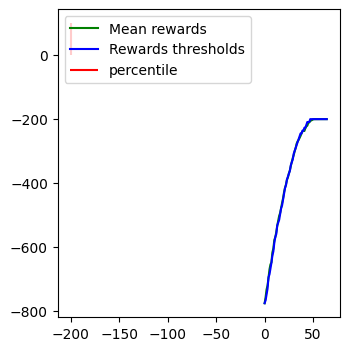

mean reward = -200.000, threshold=-200.000


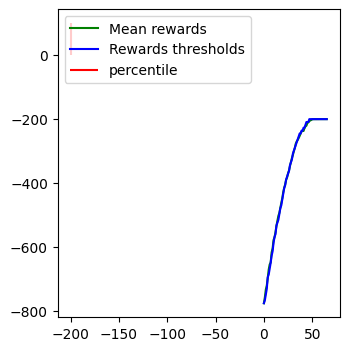

mean reward = -200.000, threshold=-200.000


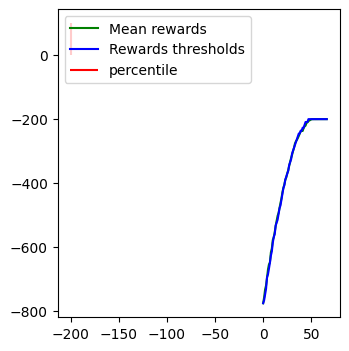

mean reward = -200.000, threshold=-200.000


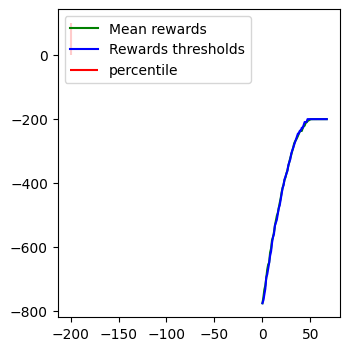

mean reward = -200.000, threshold=-200.000


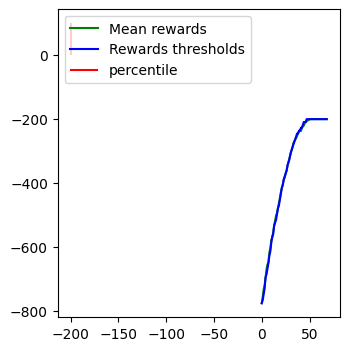

In [ ]:
def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])
    
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label='Mean rewards', color='green')
    plt.plot(list(zip(*log))[1], label='Rewards thresholds', color='blue')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines([np.percentile(rewards_batch, percentile)], [0], [100], label='percentile', color='red')
    plt.legend()
    plt.grid()

    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.show()


policy  = initialize_policy(n_states, n_actions)
n_sessions = 250
percentile = 50
learning_rate = 0.5
log = []

for i in range(100):
    sessions = [generate_session(env, policy, t_max=10**3) for _  in range(n_sessions)]
    
    states_batch,actions_batch,rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)
    new_policy = get_new_policy(elite_states, elite_actions)
    policy = learning_rate * new_policy + (1 - learning_rate) * policy
    show_progress(rewards_batch, log, percentile)